# Regressão Linear 1

Dataset: [Software Developer Salary Prediction Dataset
](https://www.kaggle.com/datasets/nudratabbas/software-developer-salary-prediction-dataset/data)

## Download

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nudratabbas/software-developer-salary-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'software-developer-salary-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/software-developer-salary-prediction-dataset


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Carregar dados

In [ ]:
df = pd.read_csv(path+'/train.csv')
df

,experience,country,education,languages,frameworks,company_size,salary_usd
0,34,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292
1,9,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311
2,8,USA,Some College,"C++, Go","Vue, React",5000+,109637
3,29,USA,Masters,"C++, Ruby","Spring, Angular",11-50,214386
4,7,USA,Bachelors,"C#, Rust","React, Express",1-10,107584
...,...,...,...,...,...,...,...
39995,38,USA,Bachelors,"Go, Java","ASP.NET, Vue",51-200,221009
39996,15,Brazil,Bachelors,"Ruby, Ruby","Django, ASP.NET",1001-5000,107678
39997,37,USA,Some College,"Rust, Python","ASP.NET, Ruby on Rails",11-50,195547
39998,27,USA,Masters,"Ruby, C++","Django, Express",1001-5000,204153


## EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   experience    40000 non-null  int64 
 1   country       40000 non-null  object
 2   education     40000 non-null  object
 3   languages     40000 non-null  object
 4   frameworks    40000 non-null  object
 5   company_size  40000 non-null  object
 6   salary_usd    40000 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB


In [ ]:
df.describe()

,experience,salary_usd
count,40000.000000,40000.000000
mean,19.912875,131834.441525
std,11.865220,46426.249810
min,0.000000,12024.000000
25%,10.000000,98172.250000
50%,20.000000,130579.000000
75%,30.000000,164431.000000
max,40.000000,277554.000000


In [ ]:
df['company_size'].value_counts()

,count
company_size,
201-1000,6846
51-200,6730
5000+,6715
11-50,6597
1001-5000,6584
1-10,6528


In [ ]:
df['country'].value_counts()

,count
country,
USA,16003
UK,4013
Canada,4003
Germany,3988
India,3970
Australia,2064
France,2031
Japan,1918
Brazil,1030


In [ ]:
df['education'].value_counts()

,count
education,
Bachelors,20061
Masters,11968
Some College,4005
High School,1988
PhD,1978


In [ ]:
df['languages'].value_counts()

,count
languages,
"Swift, Python",458
"JavaScript, JavaScript",450
"Java, Python",443
"Swift, PHP",434
"Go, Python",432
...,...
"C++, Swift",367
"Rust, C++",363
"Ruby, Ruby",360


In [ ]:
df['frameworks'].value_counts()

,count
frameworks,
"Flask, ASP.NET",446
"Ruby on Rails, Angular",441
"React, Express",440
"ASP.NET, React",440
"Angular, Flask",437
...,...
"Vue, React",366
"Angular, Vue",358
"Laravel, Angular",352


In [ ]:
df['languages'].value_counts()

,count
languages,
"Swift, Python",458
"JavaScript, JavaScript",450
"Java, Python",443
"Swift, PHP",434
"Go, Python",432
...,...
"C++, Swift",367
"Rust, C++",363
"Ruby, Ruby",360


In [ ]:
df['languages']

,languages
0,"Rust, JavaScript"
1,"C#, JavaScript"
2,"C++, Go"
3,"C++, Ruby"
4,"C#, Rust"
...,...
39995,"Go, Java"
39996,"Ruby, Ruby"
39997,"Rust, Python"
39998,"Ruby, C++"


In [ ]:
sns.set_theme(style='whitegrid')

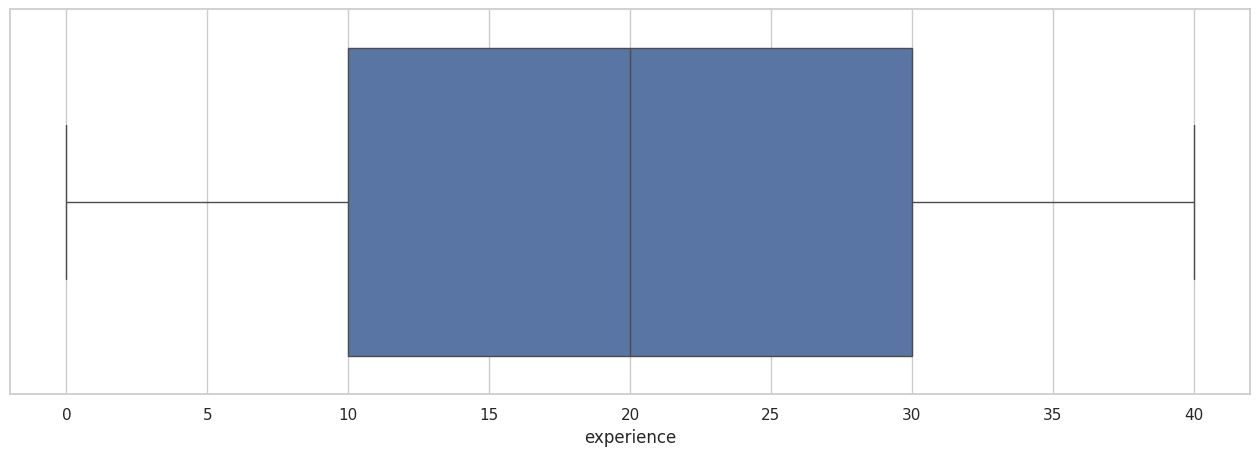

In [ ]:
plt.figure(figsize=(16,5))
sns.boxplot(x=df['experience'])
plt.show()

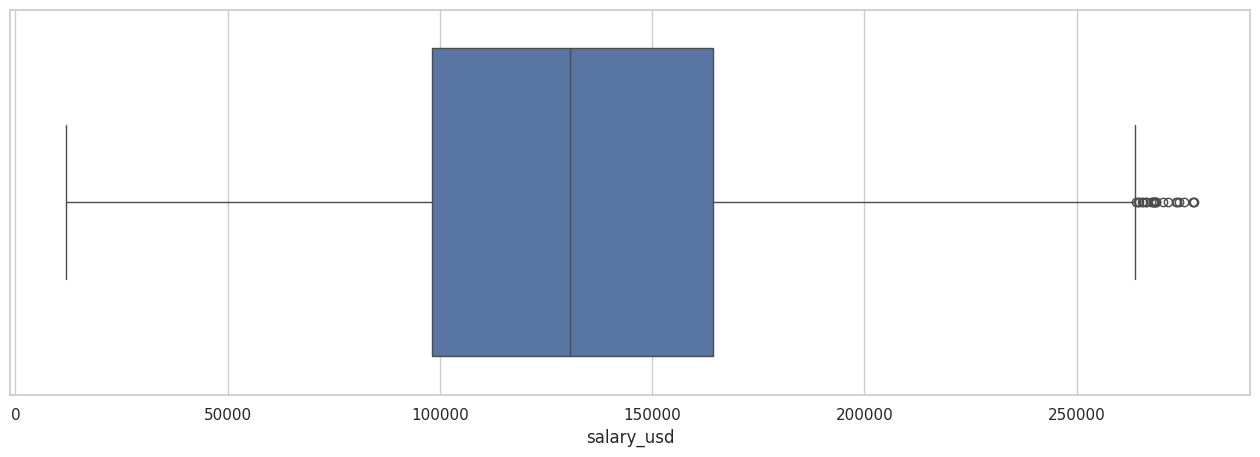

In [ ]:
plt.figure(figsize=(16,5))
sns.boxplot(x=df['salary_usd'])
plt.show()

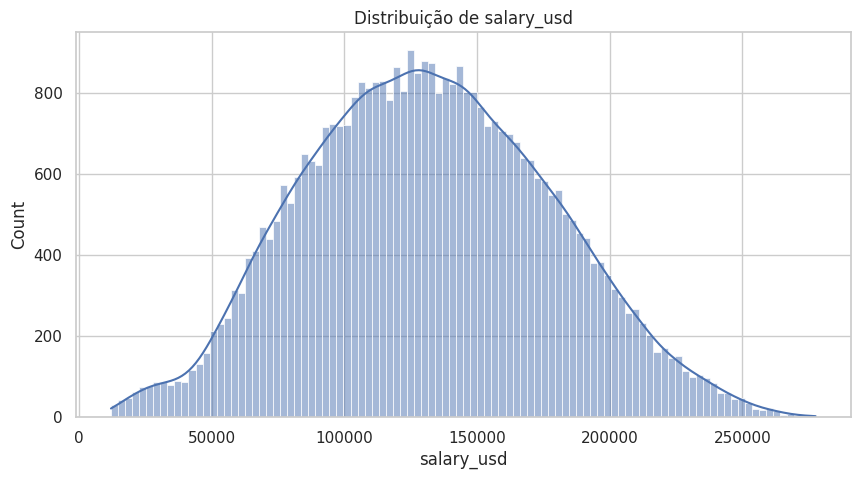

In [ ]:
def plot_histogram(df, column_name):
    plt.figure(figsize=(10, 5))
    sns.histplot(df[column_name], bins=100, kde=True)
    plt.title(f'Distribuição de {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.show()

plot_histogram(df, 'salary_usd')

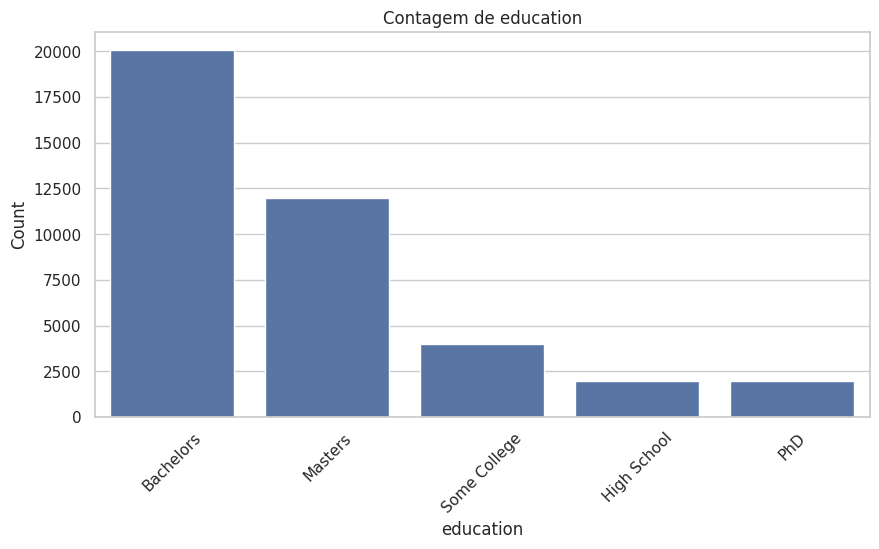

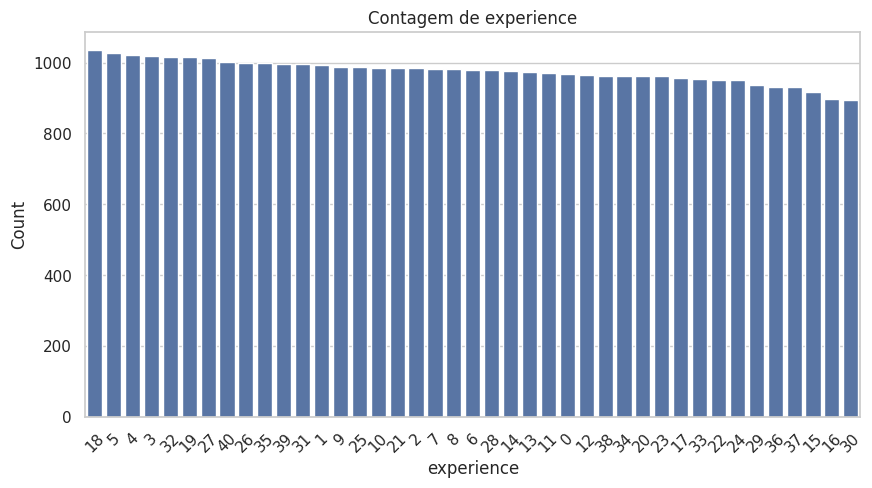

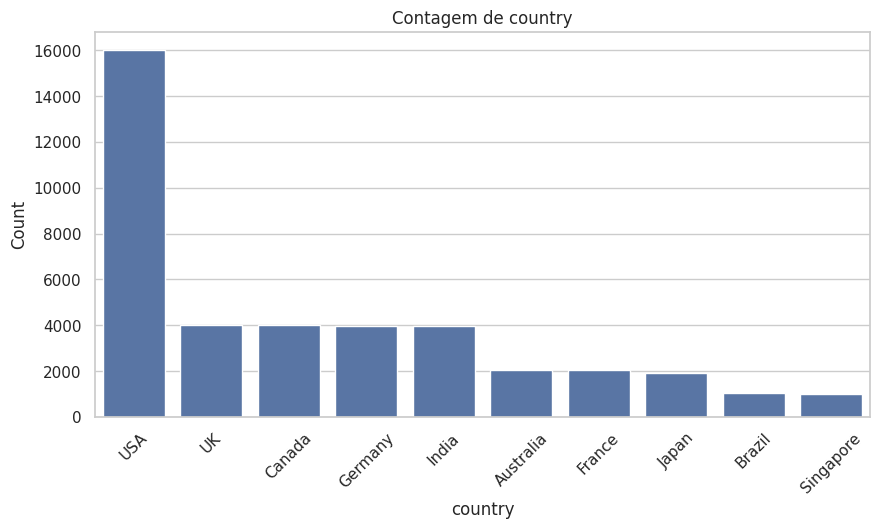

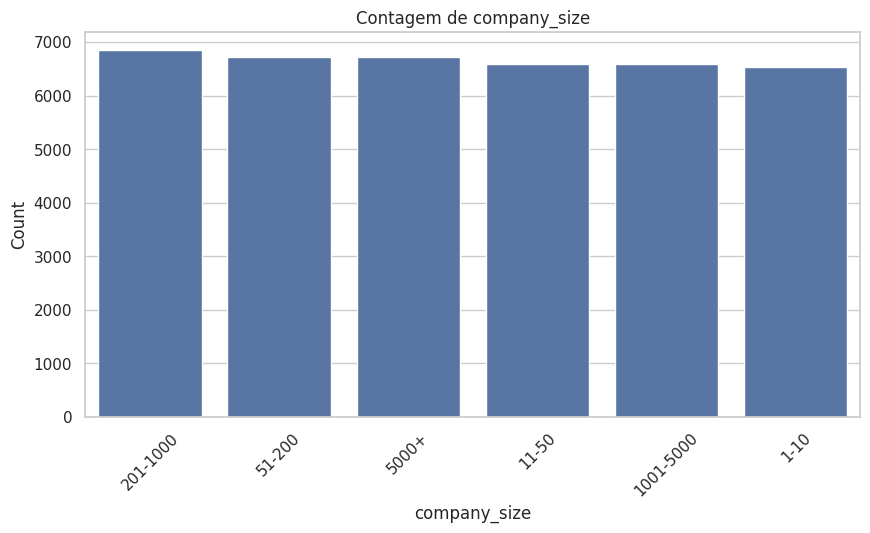

In [ ]:
def plot_countplot(df, column_name):
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=column_name, order=df[column_name].value_counts().index)
    plt.title(f'Contagem de {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

plot_countplot(df, 'education')
plot_countplot(df, 'experience')
plot_countplot(df, 'country')
plot_countplot(df, 'company_size')

In [ ]:
def plot_boxplot_by_column(df, column_name):
    plt.figure(figsize=(16,5))
    plt.title(f'Boxplot de Salário por {column_name}')
    sns.boxplot(
        x=df[column_name],
        y=df['salary_usd'],
        order=df.groupby(column_name)['salary_usd'].mean().sort_values(ascending=False).index,
        palette='viridis',
        hue=df[column_name]
    )

    plt.grid(True)
    plt.xlabel(column_name, fontsize=12)
    plt.ylabel('Salário (USD)', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

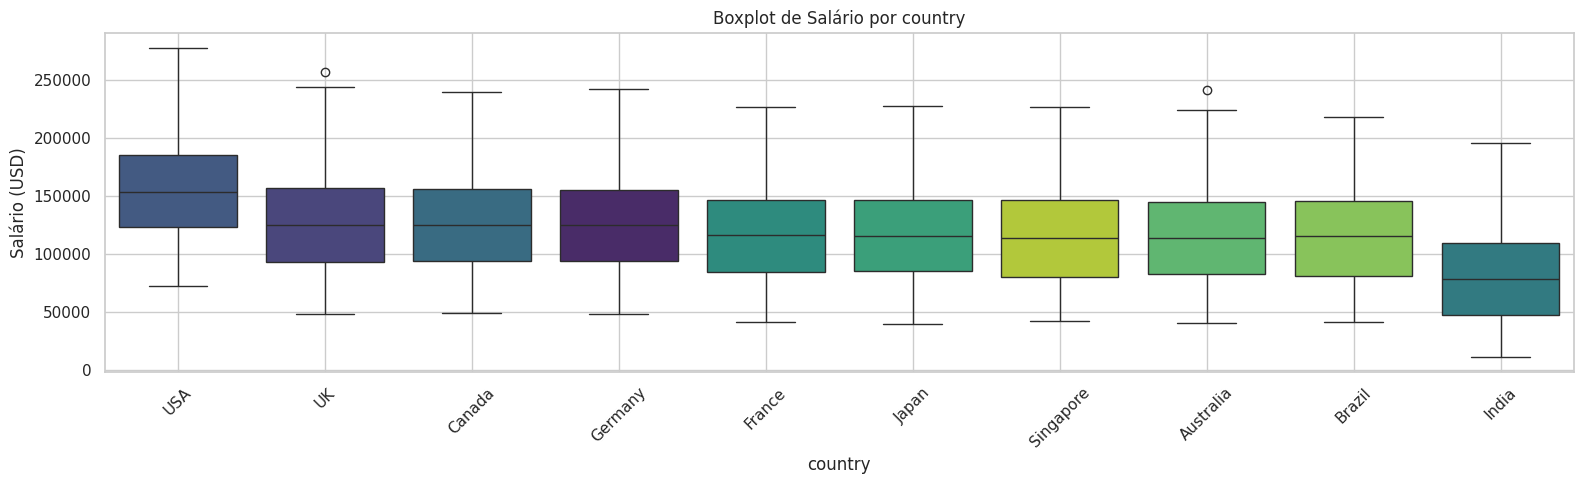

In [ ]:
plot_boxplot_by_column(df, 'country')

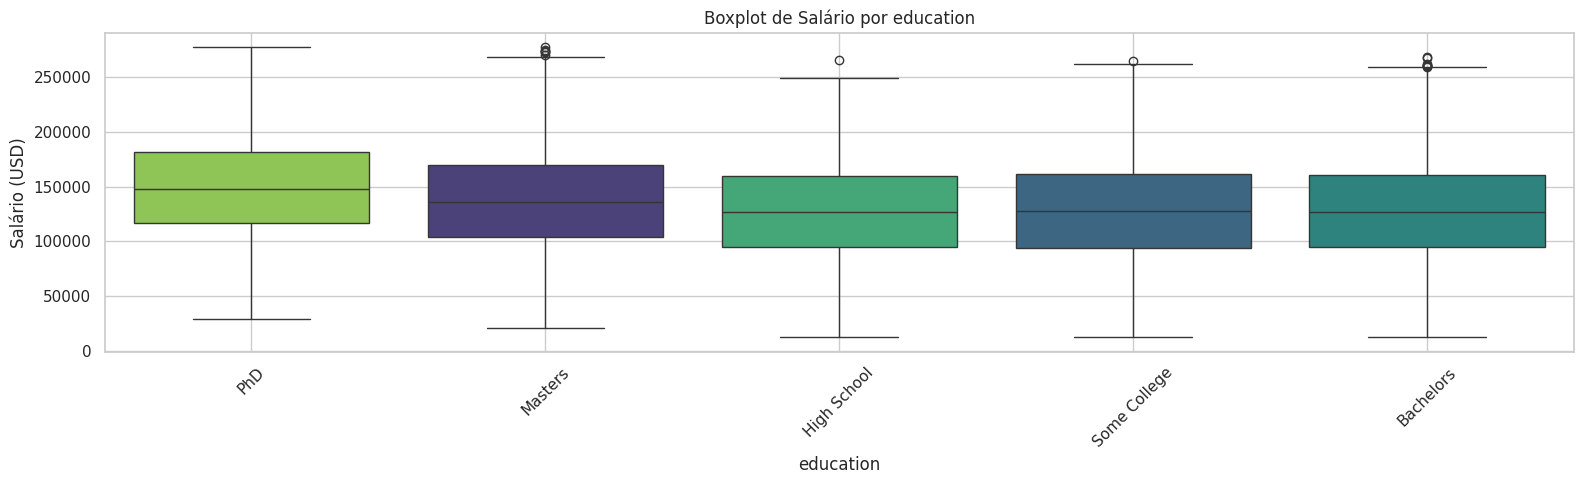

In [ ]:
plot_boxplot_by_column(df, 'education')

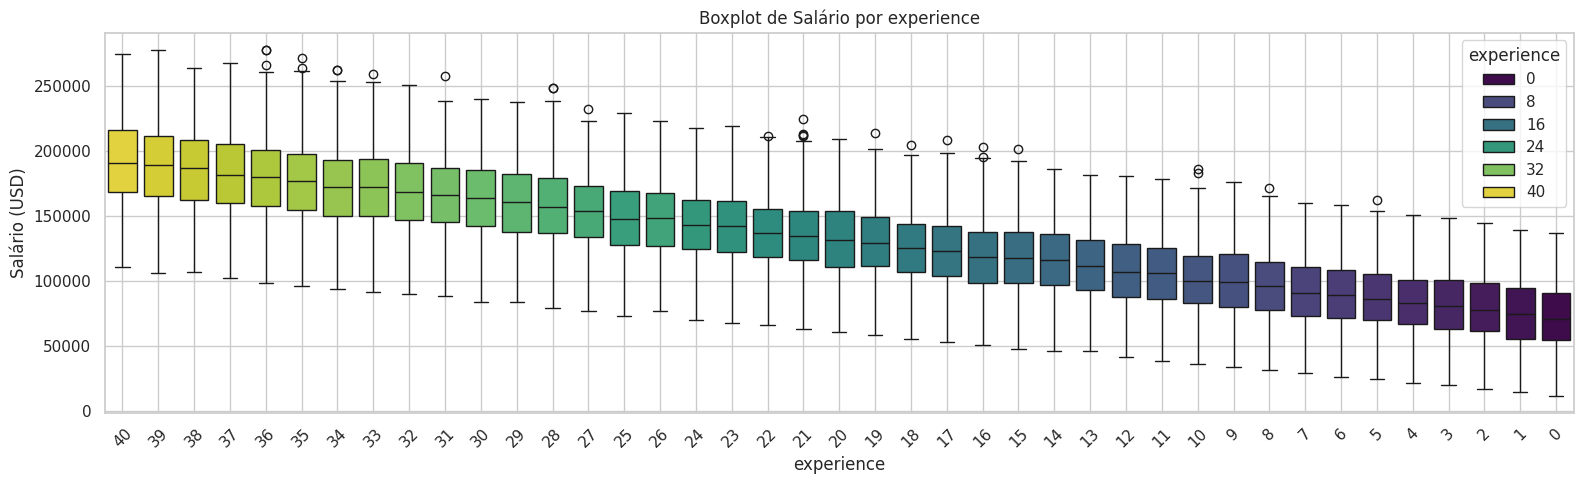

In [ ]:
plot_boxplot_by_column(df, 'experience')

In [ ]:
def plot_double_boxplot_by_column(df, column_x, column_hue):
    plt.figure(figsize=(32, 5))
    plt.title(f'Boxplot de Salário por {column_x} e {column_hue}')

    order = (
        df.groupby(column_x)['salary_usd']
        .mean()
        .sort_values(ascending=False)
        .index
    )

    sns.boxplot(
        data=df,
        x=column_x,
        y='salary_usd',
        hue=column_hue,
        order=order,
        palette='viridis'
    )

    plt.grid(True)
    plt.xlabel(column_x, fontsize=12)
    plt.ylabel('Salário (USD)', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title=column_hue, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

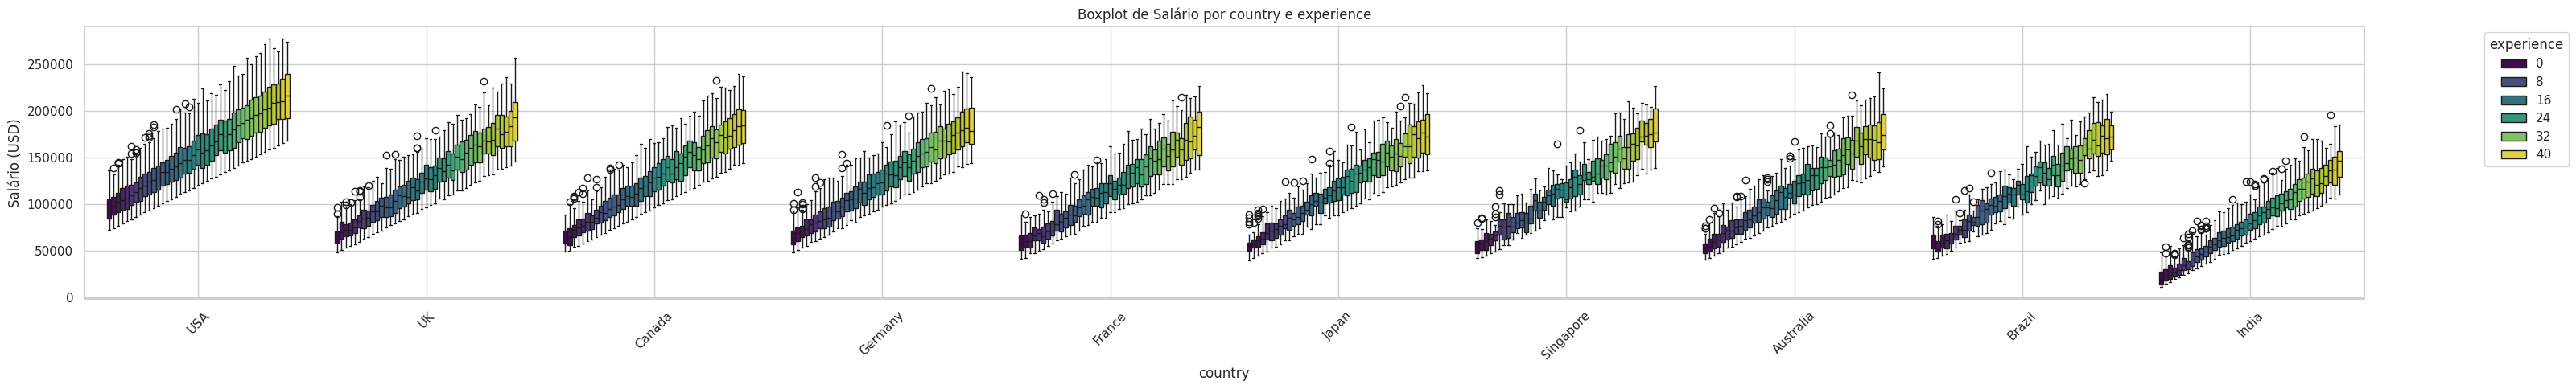

In [ ]:
plot_double_boxplot_by_column(df, 'country', 'experience')

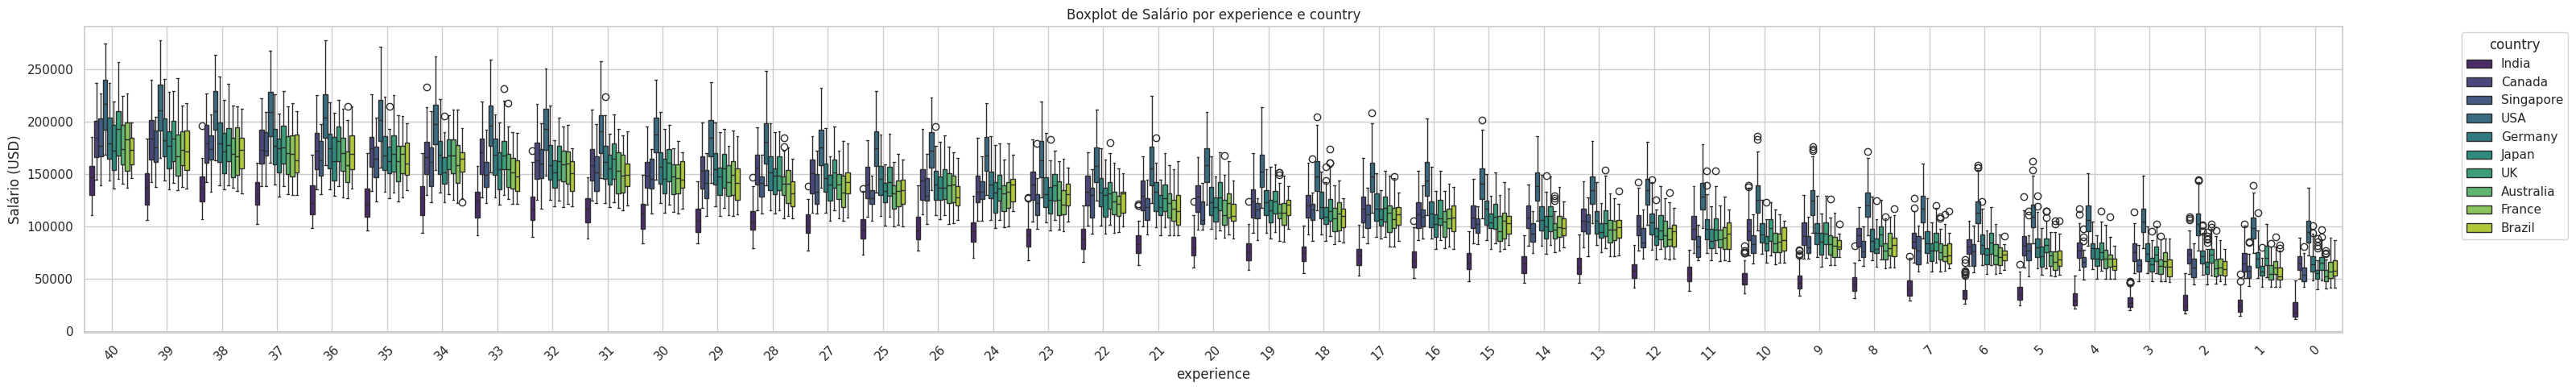

In [ ]:
plot_double_boxplot_by_column(df, 'experience', 'country')

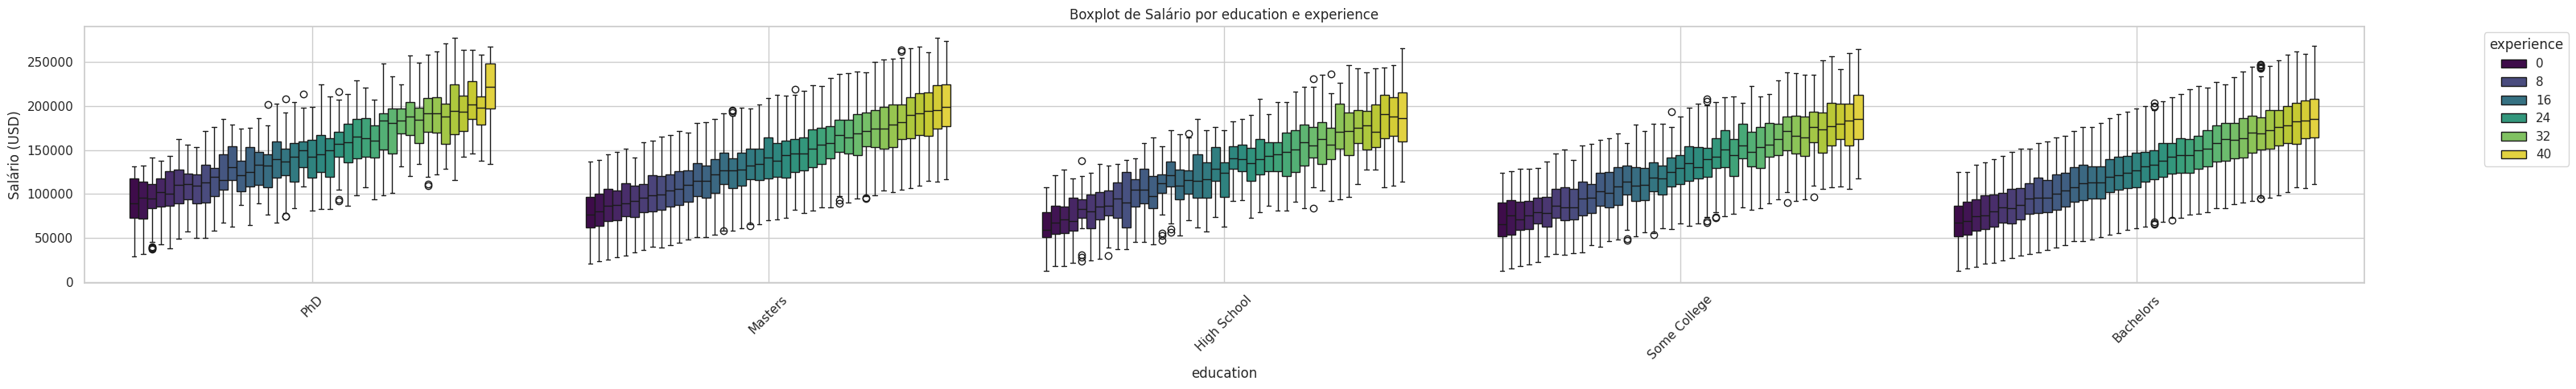

In [ ]:
plot_double_boxplot_by_column(df, 'education', 'experience')

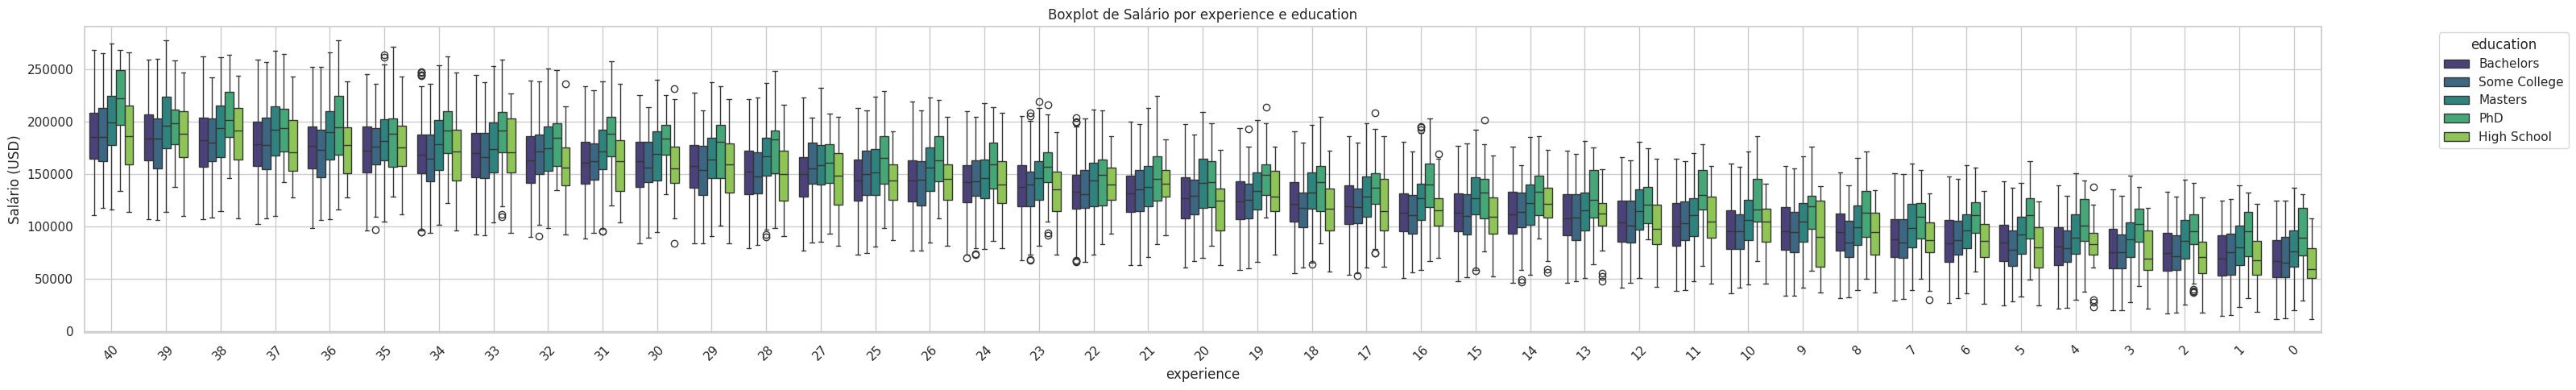

In [ ]:
plot_double_boxplot_by_column(df, 'experience', 'education')

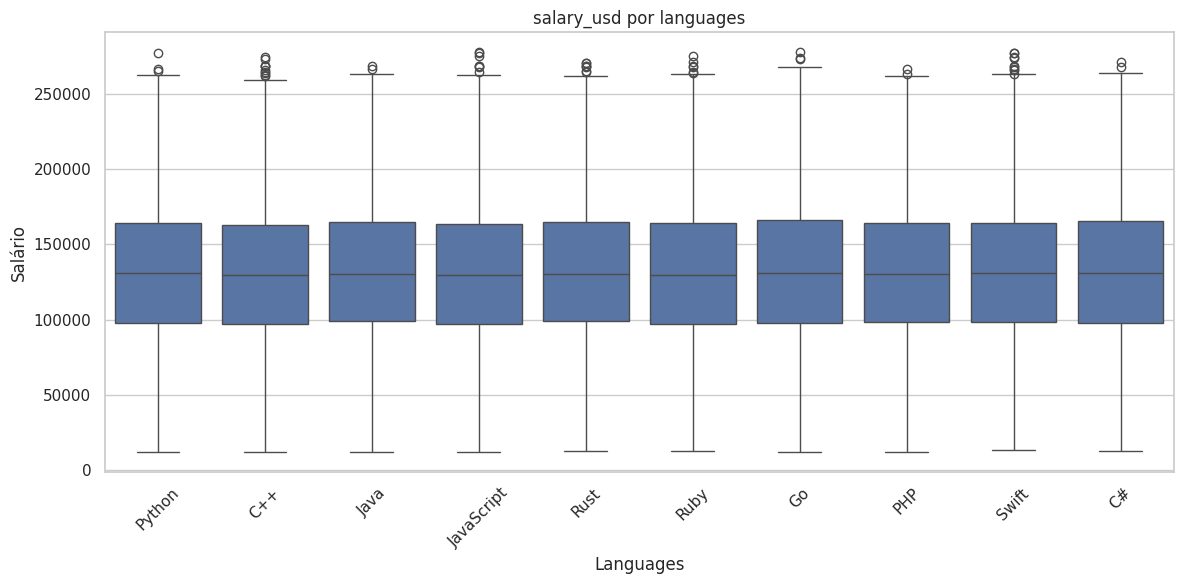

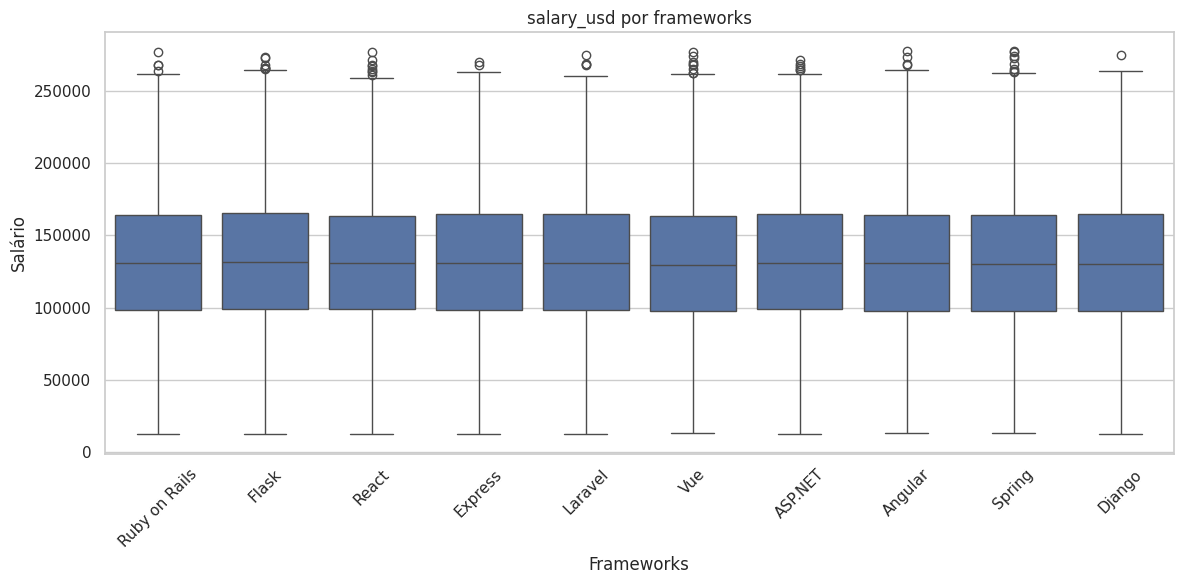

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_split_boxplot(df, column):
    temp = df.copy()

    temp[column] = temp[column].str.split(', ')
    temp = temp.explode(column)

    temp = temp.dropna(subset=[column, 'salary_usd'])

    order = temp[column].value_counts().index

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=temp, x=column, y='salary_usd', order=order)
    plt.title(f'salary_usd por {column}')
    plt.xlabel(column.capitalize())
    plt.ylabel('Salário')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_split_boxplot(df, 'languages')
plot_split_boxplot(df, 'frameworks')

## Test LR

In [ ]:
X = df.drop(columns=['salary_usd'])
y = df['salary_usd']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

try:
    model.fit(X_train, y_train) # Deve quebrar porque não tratamos as colunas categóricas
except Exception as e:
    print('#'*100)
    print(e)
    print('#'*100)

####################################################################################################
could not convert string to float: 'Japan'
####################################################################################################


In [ ]:
X = X[['experience']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MSE:', mse)
print('R²:', r2)

MSE: 872758941.0725925
R²: 0.5945964929177082


## Feature Engineer

In [ ]:
dummies_framework = df['frameworks'].str.replace(' ', '').str.get_dummies(sep=',')
dummies_framework

,ASP.NET,Angular,Django,Express,Flask,Laravel,React,RubyonRails,Spring,Vue
0,1,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,1,1,0
2,0,0,0,0,0,0,1,0,0,1
3,0,1,0,0,0,0,0,0,1,0
4,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
39995,1,0,0,0,0,0,0,0,0,1
39996,1,0,1,0,0,0,0,0,0,0
39997,1,0,0,0,0,0,0,1,0,0
39998,0,0,1,1,0,0,0,0,0,0


In [ ]:
dummies_languages = df['languages'].str.replace(' ', '').str.get_dummies(sep=',')
dummies_languages

,C#,C++,Go,Java,JavaScript,PHP,Python,Ruby,Rust,Swift
0,0,0,0,0,1,0,0,0,1,0
1,1,0,0,0,1,0,0,0,0,0
2,0,1,1,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,1,0,0
4,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
39995,0,0,1,1,0,0,0,0,0,0
39996,0,0,0,0,0,0,0,1,0,0
39997,0,0,0,0,0,0,1,0,1,0
39998,0,1,0,0,0,0,0,1,0,0


In [ ]:
df = pd.concat([df, dummies_framework], axis=1)
df = pd.concat([df, dummies_languages], axis=1)
df

,experience,country,education,languages,frameworks,company_size,salary_usd,ASP.NET,Angular,Django,...,C#,C++,Go,Java,JavaScript,PHP,Python,Ruby,Rust,Swift
0,34,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292,1,0,0,...,0,0,0,0,1,0,0,0,1,0
1,9,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311,0,0,0,...,1,0,0,0,1,0,0,0,0,0
2,8,USA,Some College,"C++, Go","Vue, React",5000+,109637,0,0,0,...,0,1,1,0,0,0,0,0,0,0
3,29,USA,Masters,"C++, Ruby","Spring, Angular",11-50,214386,0,1,0,...,0,1,0,0,0,0,0,1,0,0
4,7,USA,Bachelors,"C#, Rust","React, Express",1-10,107584,0,0,0,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,38,USA,Bachelors,"Go, Java","ASP.NET, Vue",51-200,221009,1,0,0,...,0,0,1,1,0,0,0,0,0,0
39996,15,Brazil,Bachelors,"Ruby, Ruby","Django, ASP.NET",1001-5000,107678,1,0,1,...,0,0,0,0,0,0,0,1,0,0
39997,37,USA,Some College,"Rust, Python","ASP.NET, Ruby on Rails",11-50,195547,1,0,0,...,0,0,0,0,0,0,1,0,1,0
39998,27,USA,Masters,"Ruby, C++","Django, Express",1001-5000,204153,0,0,1,...,0,1,0,0,0,0,0,1,0,0


In [ ]:
df = df.drop(['frameworks', 'languages'], axis=1)
df

,experience,country,education,company_size,salary_usd,ASP.NET,Angular,Django,Express,Flask,...,C#,C++,Go,Java,JavaScript,PHP,Python,Ruby,Rust,Swift
0,34,Germany,Masters,201-1000,172292,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,9,UK,Masters,201-1000,82311,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
2,8,USA,Some College,5000+,109637,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
3,29,USA,Masters,11-50,214386,0,1,0,0,0,...,0,1,0,0,0,0,0,1,0,0
4,7,USA,Bachelors,1-10,107584,0,0,0,1,0,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,38,USA,Bachelors,51-200,221009,1,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
39996,15,Brazil,Bachelors,1001-5000,107678,1,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
39997,37,USA,Some College,11-50,195547,1,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
39998,27,USA,Masters,1001-5000,204153,0,0,1,1,0,...,0,1,0,0,0,0,0,1,0,0


In [ ]:
education_map = {
    'High School': 0,
    'Some College': 1,
    'Bachelors': 2,
    'Masters': 3,
    'PhD': 4,
}

df['education_level'] = df['education'].map(education_map)
df

,experience,country,education,company_size,salary_usd,ASP.NET,Angular,Django,Express,Flask,...,C++,Go,Java,JavaScript,PHP,Python,Ruby,Rust,Swift,education_level
0,34,Germany,Masters,201-1000,172292,1,0,0,0,0,...,0,0,0,1,0,0,0,1,0,3
1,9,UK,Masters,201-1000,82311,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,3
2,8,USA,Some College,5000+,109637,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,1
3,29,USA,Masters,11-50,214386,0,1,0,0,0,...,1,0,0,0,0,0,1,0,0,3
4,7,USA,Bachelors,1-10,107584,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,38,USA,Bachelors,51-200,221009,1,0,0,0,0,...,0,1,1,0,0,0,0,0,0,2
39996,15,Brazil,Bachelors,1001-5000,107678,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,2
39997,37,USA,Some College,11-50,195547,1,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1
39998,27,USA,Masters,1001-5000,204153,0,0,1,1,0,...,1,0,0,0,0,0,1,0,0,3


In [ ]:
df = df.drop(['education'], axis=1)

In [ ]:
df = pd.concat([df, pd.get_dummies(df['company_size'])], axis=1)
df

,experience,country,company_size,salary_usd,ASP.NET,Angular,Django,Express,Flask,Laravel,...,Ruby,Rust,Swift,education_level,1-10,1001-5000,11-50,201-1000,5000+,51-200
0,34,Germany,201-1000,172292,1,0,0,0,0,0,...,0,1,0,3,False,False,False,True,False,False
1,9,UK,201-1000,82311,0,0,0,0,0,0,...,0,0,0,3,False,False,False,True,False,False
2,8,USA,5000+,109637,0,0,0,0,0,0,...,0,0,0,1,False,False,False,False,True,False
3,29,USA,11-50,214386,0,1,0,0,0,0,...,1,0,0,3,False,False,True,False,False,False
4,7,USA,1-10,107584,0,0,0,1,0,0,...,0,1,0,2,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,38,USA,51-200,221009,1,0,0,0,0,0,...,0,0,0,2,False,False,False,False,False,True
39996,15,Brazil,1001-5000,107678,1,0,1,0,0,0,...,1,0,0,2,False,True,False,False,False,False
39997,37,USA,11-50,195547,1,0,0,0,0,0,...,0,1,0,1,False,False,True,False,False,False
39998,27,USA,1001-5000,204153,0,0,1,1,0,0,...,1,0,0,3,False,True,False,False,False,False


In [ ]:
df = df.drop(['company_size'], axis=1)
df

,experience,country,salary_usd,ASP.NET,Angular,Django,Express,Flask,Laravel,React,...,Ruby,Rust,Swift,education_level,1-10,1001-5000,11-50,201-1000,5000+,51-200
0,34,Germany,172292,1,0,0,0,0,0,0,...,0,1,0,3,False,False,False,True,False,False
1,9,UK,82311,0,0,0,0,0,0,0,...,0,0,0,3,False,False,False,True,False,False
2,8,USA,109637,0,0,0,0,0,0,1,...,0,0,0,1,False,False,False,False,True,False
3,29,USA,214386,0,1,0,0,0,0,0,...,1,0,0,3,False,False,True,False,False,False
4,7,USA,107584,0,0,0,1,0,0,1,...,0,1,0,2,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,38,USA,221009,1,0,0,0,0,0,0,...,0,0,0,2,False,False,False,False,False,True
39996,15,Brazil,107678,1,0,1,0,0,0,0,...,1,0,0,2,False,True,False,False,False,False
39997,37,USA,195547,1,0,0,0,0,0,0,...,0,1,0,1,False,False,True,False,False,False
39998,27,USA,204153,0,0,1,1,0,0,0,...,1,0,0,3,False,True,False,False,False,False


In [ ]:
df = pd.concat([df, pd.get_dummies(df['country'])], axis=1)
df

,experience,country,salary_usd,ASP.NET,Angular,Django,Express,Flask,Laravel,React,...,Australia,Brazil,Canada,France,Germany,India,Japan,Singapore,UK,USA
0,34,Germany,172292,1,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False
1,9,UK,82311,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
2,8,USA,109637,0,0,0,0,0,0,1,...,False,False,False,False,False,False,False,False,False,True
3,29,USA,214386,0,1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,True
4,7,USA,107584,0,0,0,1,0,0,1,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,38,USA,221009,1,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,True
39996,15,Brazil,107678,1,0,1,0,0,0,0,...,False,True,False,False,False,False,False,False,False,False
39997,37,USA,195547,1,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,True
39998,27,USA,204153,0,0,1,1,0,0,0,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
df = df.drop(['country'], axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 39 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   experience       40000 non-null  int64
 1   salary_usd       40000 non-null  int64
 2   ASP.NET          40000 non-null  int64
 3   Angular          40000 non-null  int64
 4   Django           40000 non-null  int64
 5   Express          40000 non-null  int64
 6   Flask            40000 non-null  int64
 7   Laravel          40000 non-null  int64
 8   React            40000 non-null  int64
 9   RubyonRails      40000 non-null  int64
 10  Spring           40000 non-null  int64
 11  Vue              40000 non-null  int64
 12  C#               40000 non-null  int64
 13  C++              40000 non-null  int64
 14  Go               40000 non-null  int64
 15  Java             40000 non-null  int64
 16  JavaScript       40000 non-null  int64
 17  PHP              40000 non-null  int64
 18  Python

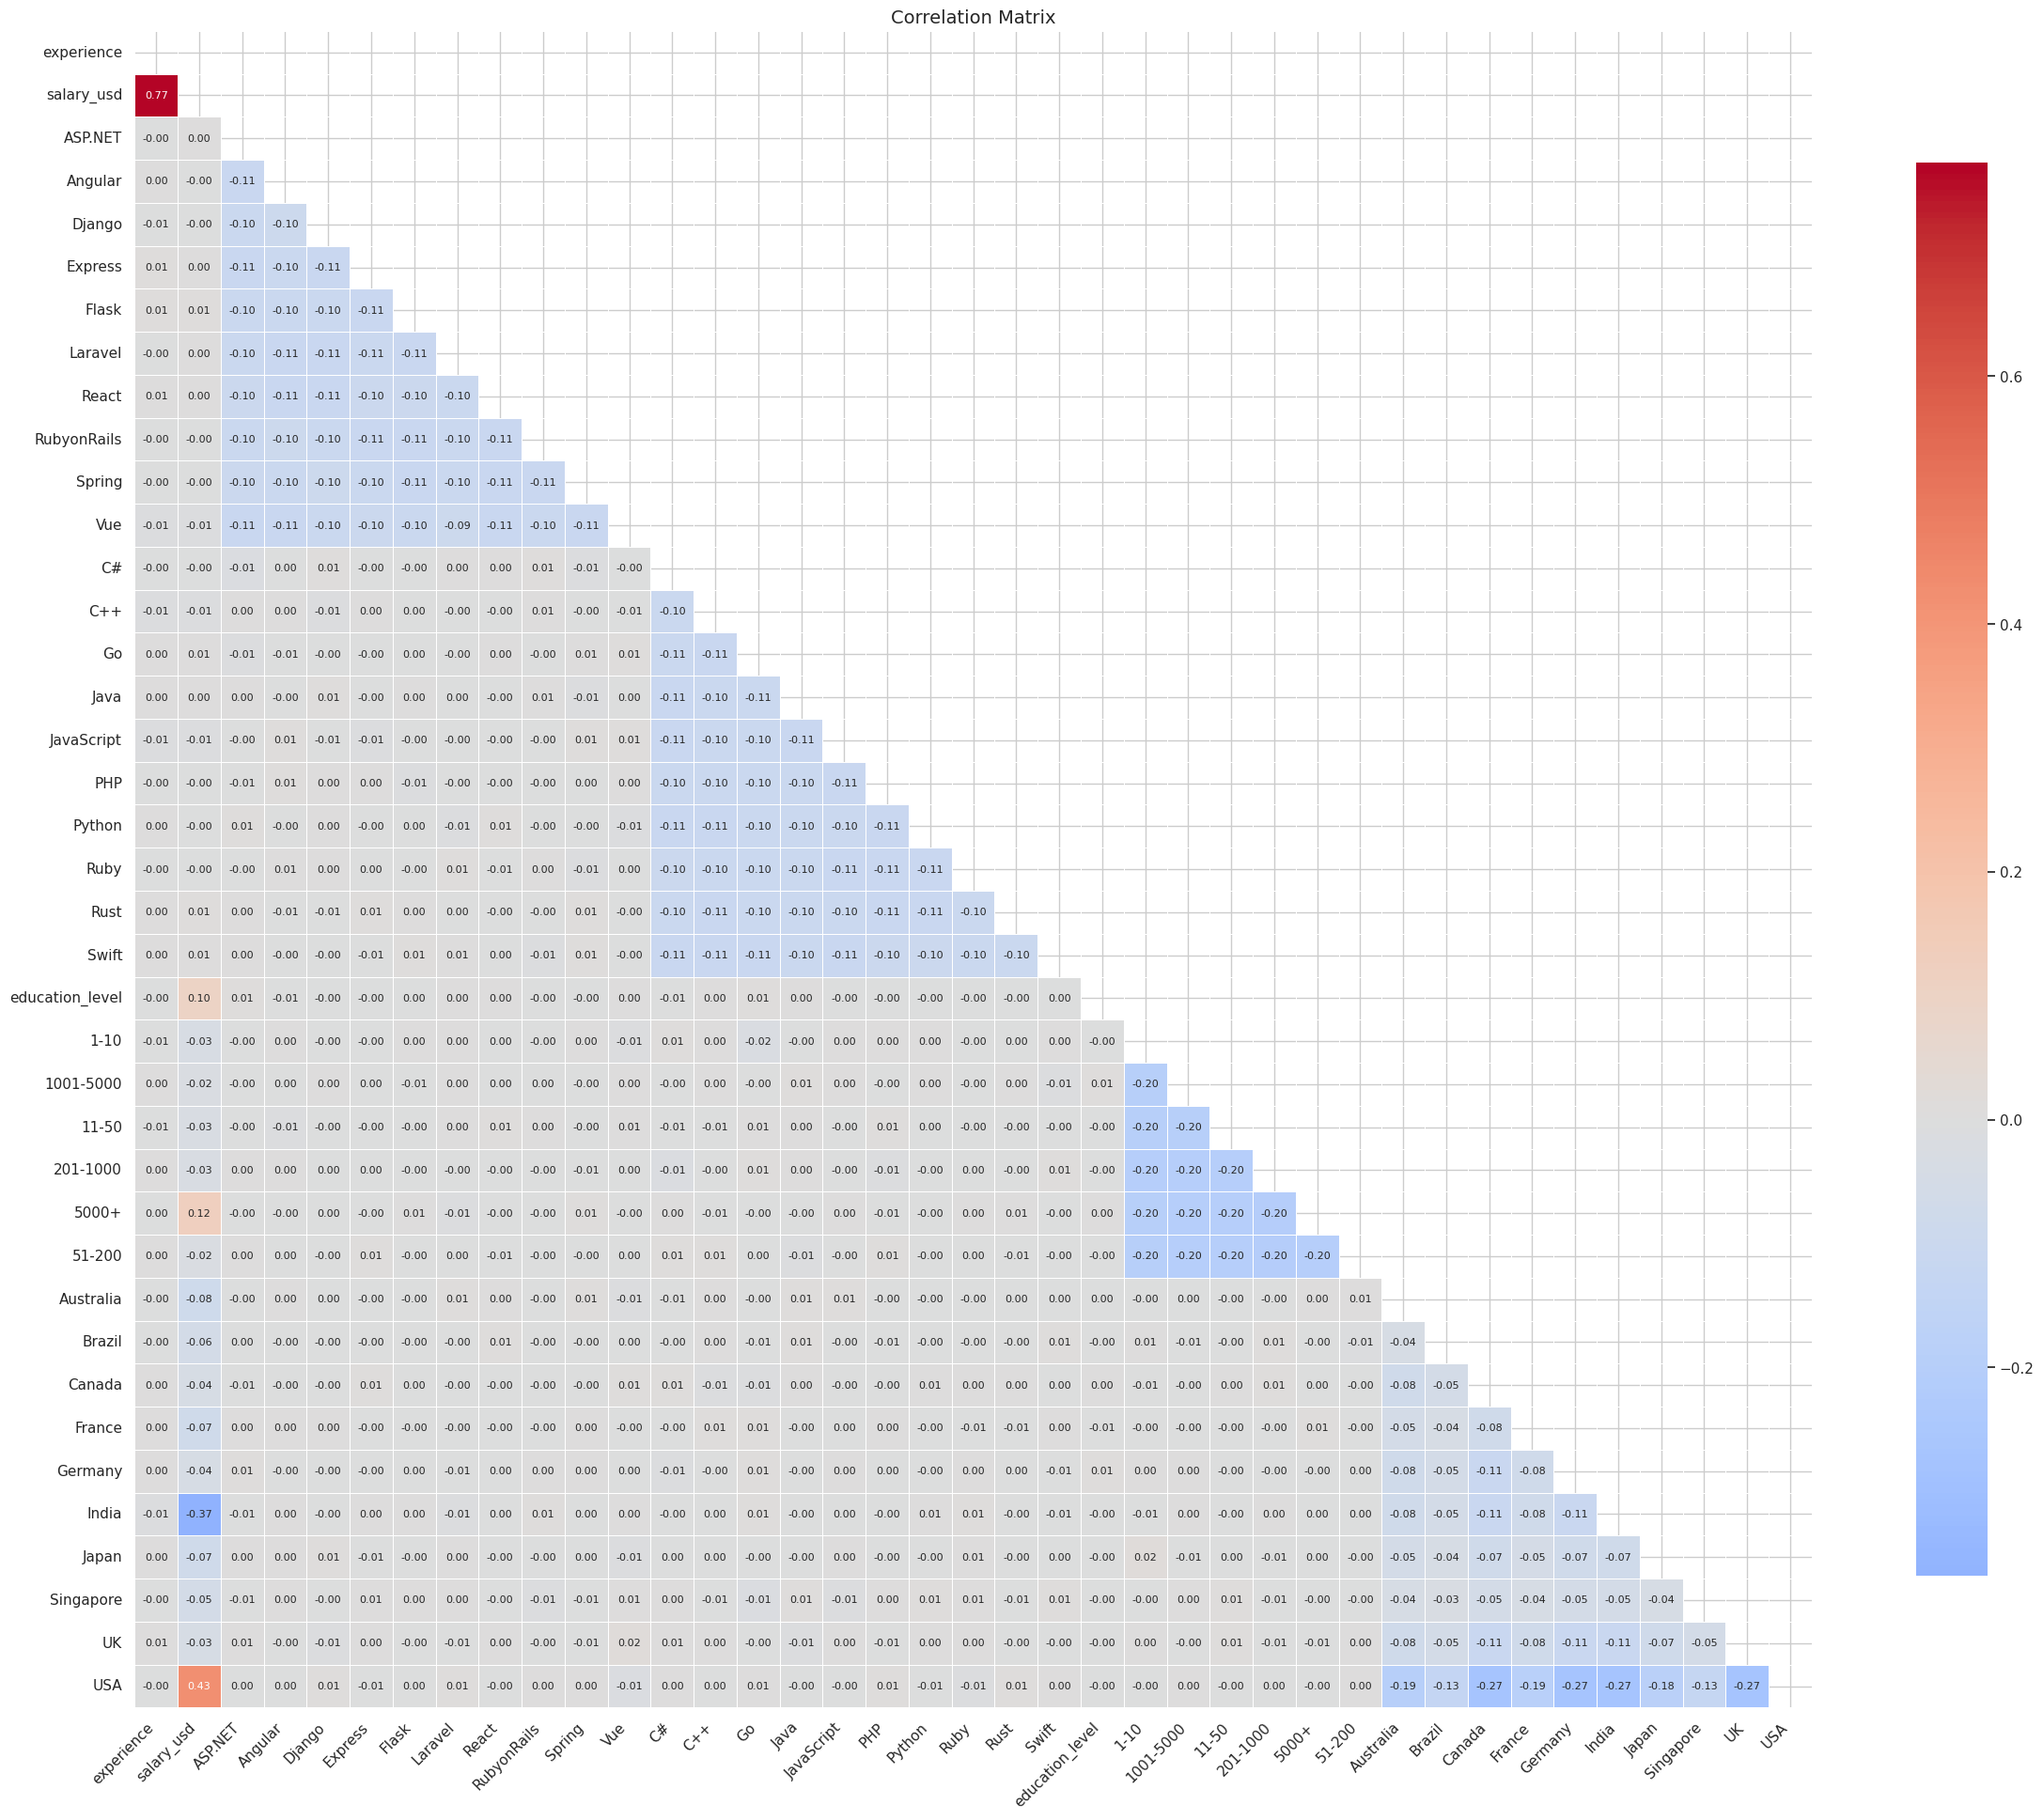

In [ ]:
corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(24, 20))

sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    vmin=corr.min().min(),
    vmax=corr[corr<1].max().max(),
    center=0,
    square=True,
    linewidths=0.5,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8},
)

plt.title('Correlation Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## LR

In [ ]:
X = df.drop(columns=['salary_usd'])
y = df['salary_usd']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MSE:', mse)
print('R²:', r2)

MSE: 273201749.23585844
R²: 0.8730956028418143


In [ ]:
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
}).sort_values(by='coefficient', ascending=False)

print(coefficients)

            feature   coefficient
37              USA  36269.998743
26            5000+  12881.604776
36               UK   6871.609120
30           Canada   5979.788760
32          Germany   5768.265330
21  education_level   5499.328842
0        experience   3014.854690
18             Ruby    506.045251
17           Python    416.831214
6           Laravel    343.672253
14             Java    277.771887
13               Go    266.331591
19             Rust    250.242957
20            Swift    194.649557
4           Express    154.517615
5             Flask    100.175326
8       RubyonRails     21.662177
10              Vue    -56.063395
1           ASP.NET    -64.395851
11               C#    -64.748711
9            Spring    -71.447162
15       JavaScript    -73.679034
12              C++   -105.831247
2           Angular   -111.019195
7             React   -116.504638
3            Django   -327.334546
16              PHP   -327.990393
23        1001-5000  -2358.457243
24            